## Script for Rescoring Epochs 

In [2]:
import pandas as pd
import numpy as np 
from matplotlib import pyplot as plt
import matplotlib


In [4]:
# load in sheets 
zeynep_scores = pd.read_excel("zeynep_rescore.xlsx")
basak_scores = pd.read_excel("Basak_rescore.xlsx")
algo_scores_data = pd.read_pickle("mismatch_df.pkl")

In [4]:
zeynep_scores.head()

,Epoch,Muscle_type,Response_start_sample,Response_end_sample,Contraction_number
0,0,Corr,157,1943,0
1,0,Zygo,222,736,3
2,1,Corr,12,2233,0
3,1,Zygo,1449,1739,1
4,2,Corr,47,2188,0


In [5]:
# extract contraction number and muscle type info from algo_scores to directly compare 
df_template = algo_scores_data.copy()
algo_scores_data = algo_scores_data.rename(columns = {"Nap Number": "Nap"})

df_template = df_template.drop(columns=[
    "Zygo",
    "Corr",
    "Num_Contractions_Zygo",
    "Num_Contractions_Corr"
])

df_template = df_template.rename(columns={
    "Prediction_Corr": "Corr",
    "Prediction_Zygo": "Zygo",
    "Nap Number": "Nap",
})

df_template["Epoch"] = range(len(df_template))

algo_scores = df_template.melt(
    id_vars=["Subject", "Nap","Triggers_Order_Nap", "Epoch"],
    value_vars=["Corr", "Zygo"],
    var_name="Muscle_type",
    value_name="Contraction_number"
)

algo_scores = algo_scores.sort_values(
    ["Subject", "Nap", "Triggers_Order_Nap","Epoch", "Muscle_type"]
).reset_index(drop=True)

In [6]:
algo_scores.to_excel("algo_scores_mismatch.xlsx", index=False)

Visualizations 

How many values match between the models 

In [4]:
num_epoch = np.shape(basak_scores)
num_epoch_muscle = round(np.shape(basak_scores)[0]/2)

# separating out by muscle 
basak_scores_zygo = basak_scores[basak_scores["Muscle_type"] == "Zygo"]
zeynep_scores_zygo = zeynep_scores[zeynep_scores["Muscle_type"] == "Zygo"]
algo_scores_zygo = algo_scores[algo_scores["Muscle_type"] == "Zygo"]

basak_scores_corr = basak_scores[basak_scores["Muscle_type"] == "Corr"]
zeynep_scores_corr = zeynep_scores[zeynep_scores["Muscle_type"] == "Corr"]
algo_scores_corr = algo_scores[algo_scores["Muscle_type"] == "Corr"]


# not sorting between muscles 
basak_algo_match_ind = basak_scores["Contraction_number"] == algo_scores["Contraction_number"] 
zeynep_algo_match_ind  = zeynep_scores["Contraction_number"] == algo_scores["Contraction_number"]
basak_zeynep_match_ind  = zeynep_scores["Contraction_number"] == basak_scores["Contraction_number"]

basak_algo_match_zygo_ind = basak_scores_zygo["Contraction_number"] == algo_scores_zygo["Contraction_number"] 
zeynep_algo_match_zygo_ind  = zeynep_scores_zygo["Contraction_number"] == algo_scores_zygo["Contraction_number"] 
basak_zeynep_match_zygo_ind  = zeynep_scores_zygo["Contraction_number"] == basak_scores_zygo["Contraction_number"] 


basak_algo_match_corr_ind = basak_scores_corr["Contraction_number"] == algo_scores_corr["Contraction_number"] 
zeynep_algo_match_corr_ind  = zeynep_scores_corr["Contraction_number"] == algo_scores_corr["Contraction_number"] 
basak_zeynep_match_corr_ind  = zeynep_scores_corr["Contraction_number"] == basak_scores_corr["Contraction_number"] 


# overall match percentage 
basak_algo_match = (basak_algo_match_ind).sum()/(num_epoch)[0]*100
zeynep_algo_match  = (zeynep_algo_match_ind).sum()/(num_epoch)[0]*100
basak_zeynep_match = (basak_zeynep_match_ind).sum()/(num_epoch)[0]*100

# zygo alone 
basak_algo_zygo_match = (basak_algo_match_zygo_ind).sum()/(num_epoch_muscle)*100
zeynep_algo_zygo_match  = (zeynep_algo_match_zygo_ind).sum()/(num_epoch_muscle)*100
basak_zeynep_zygo_match = (basak_zeynep_match_zygo_ind).sum()/(num_epoch_muscle)*100

# corru alone 
basak_algo_corr_match = (basak_algo_match_corr_ind).sum()/(num_epoch_muscle)*100
zeynep_algo_corr_match  = (zeynep_algo_match_corr_ind).sum()/(num_epoch_muscle)*100
basak_zeynep_corr_match = (basak_zeynep_match_corr_ind).sum()/(num_epoch_muscle)*100


In [15]:
values = ["Basak-Algo", "Zeynep-Algo", "Zeynep-Basak"]
heights = [basak_algo_match,zeynep_algo_match,basak_zeynep_match]

bars = plt.bar(values, heights,color="blue")

plt.bar(values, [basak_algo_match,zeynep_algo_match,basak_zeynep_match])
plt.title("Algorithm Scorer Overlap")
plt.xlabel("Compared Groups")
plt.ylabel("Percent Overlap")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             str(round(yval)),
             ha='center', va='bottom')

plt.show()

# bar plot on muscle groups 
zygo_values = [basak_algo_zygo_match,zeynep_algo_zygo_match,basak_zeynep_zygo_match]
corr_values =[basak_algo_corr_match,zeynep_algo_corr_match,basak_zeynep_corr_match]

x = np.arange(len(values))
width = 0.35

bars1 = plt.bar(x - width/2, zygo_values, width, label="Zygo")
bars2 = plt.bar(x + width/2, corr_values, width, label="Corr")
plt.title("Algorithm Scorer Overlap Grouped by Muscle")

for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
                str(round(yval)),
                ha='center', va='bottom')
for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
                str(round(yval)),
                ha='center', va='bottom')
          
plt.xticks(x, values)
plt.xlabel("Compared Groups")
plt.ylabel("Percent Overlap")
plt.legend()

plt.show()

KeyboardInterrupt: 

Trying heatmap

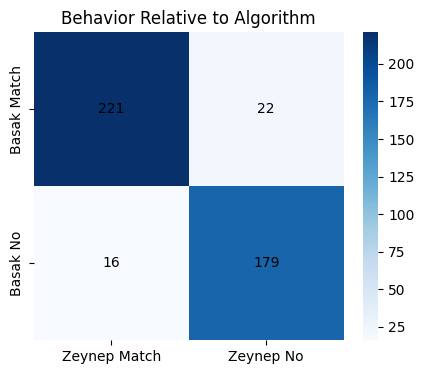

In [5]:
a = basak_algo_match_ind
b = zeynep_algo_match_ind

table = np.array([
    [np.sum((a==True) & (b==True)),   np.sum((a==True) & (b==False))],
    [np.sum((a==False) & (b==True)),  np.sum((a==False) & (b==False))]
])

labels = [["Both Match", "Basak Only"],
          ["Zeynep Only", "Neither Match"]]

plt.figure(figsize=(5,4))
sns.heatmap(table, annot=False, fmt="d", cmap="Blues",
            xticklabels=["Zeynep Match", "Zeynep No"],
            yticklabels=["Basak Match", "Basak No"])

for i in range(table.shape[0]):
    for j in range(table.shape[1]):
        plt.text(j + 0.5, i + 0.5, str(table[i, j]),
                 ha='center', va='center', color='black')
        
plt.title("Behavior Relative to Algorithm")
plt.show()

Heatmap sorted by muscle

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- mask by muscle ---
mask_zygo = basak_scores["Muscle_type"] == "Zygo"
mask_corr = basak_scores["Muscle_type"] == "Corr"

# --- Zygo ---
a_z = basak_algo_match_ind[mask_zygo]
b_z = zeynep_algo_match_ind[mask_zygo]

table_zygo = np.array([
    [np.sum((a_z==True) & (b_z==True)),   np.sum((a_z==True) & (b_z==False))],
    [np.sum((a_z==False) & (b_z==True)),  np.sum((a_z==False) & (b_z==False))]
])

# --- Corr ---
a_c = basak_algo_match_ind[mask_corr]
b_c = zeynep_algo_match_ind[mask_corr]

table_corr = np.array([
    [np.sum((a_c==True) & (b_c==True)),   np.sum((a_c==True) & (b_c==False))],
    [np.sum((a_c==False) & (b_c==True)),  np.sum((a_c==False) & (b_c==False))]
])

# --- Plot side-by-side ---
fig, axes = plt.subplots(1, 2, figsize=(10,4))

# Zygo heatmap
sns.heatmap(table_zygo, annot=False, cmap="Blues",
            xticklabels=["Zeynep Match", "Zeynep No"],
            yticklabels=["Basak Match", "Basak No"],
            ax=axes[0])
axes[0].set_title("Zygo")

# add numbers manually
for i in range(table_zygo.shape[0]):
    for j in range(table_zygo.shape[1]):
        axes[0].text(j + 0.5, i + 0.5, str(table_zygo[i, j]),
                     ha='center', va='center', color='black')

# Corr heatmap
sns.heatmap(table_corr, annot=False, cmap="Blues",
            xticklabels=["Zeynep Match", "Zeynep No"],
            yticklabels=["Basak Match", "Basak No"],
            ax=axes[1])
axes[1].set_title("Corr")

# add numbers manually
for i in range(table_corr.shape[0]):
    for j in range(table_corr.shape[1]):
        axes[1].text(j + 0.5, i + 0.5, str(table_corr[i, j]),
                     ha='center', va='center', color='black')

plt.suptitle("Behavior Relative to Algorithm by Muscle")
plt.tight_layout()
plt.show()

Match by Contraction Number

In [ ]:
total_matches = zeynep_algo_match_ind.sum()
print(total_matches)
print(grouped["zeynep_algo_match"].sum())


In [19]:
df_together = pd.DataFrame({
    "basak": basak_scores["Contraction_number"],
    "zeynep": zeynep_scores["Contraction_number"],
    "algo": algo_scores["Contraction_number"],
    "muscle": basak_scores["Muscle_type"]  
})

df_together["basak_algo_match"] = df_together["basak"] == df_together["algo"]
df_together["zeynep_algo_match"] = df_together["zeynep"] == df_together["algo"]
df_together["basak_zeynep_match"] = df_together["basak"] == df_together["zeynep"]

df_zygo = df_together[df_together["muscle"] == "Zygo"]
df_corr = df_together[df_together["muscle"] == "Corr"]

grouped = df_together.groupby("algo").agg({
    "basak_algo_match": "sum",
    "zeynep_algo_match": "sum",
    "basak_zeynep_match": "sum"
})  

grouped_zygo = df_zygo.groupby("algo").agg({
    "basak_algo_match": "sum",
    "zeynep_algo_match": "sum",
    "basak_zeynep_match": "sum"
})

grouped_corr = df_corr.groupby("algo").agg({
    "basak_algo_match": "sum",
    "zeynep_algo_match": "sum",
    "basak_zeynep_match": "sum"
})


''' 
grouped.plot(kind="bar", figsize=(10,6))

plt.ylabel("Number of Matches")
plt.xlabel("Contractions from Algorithm")
plt.title("Agreement by Contraction Number")

plt.legend(["Basak-Algo", "Zeynep-Algo", "Basak-Zeynep"])
plt.show()
'''

fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

# Zygo
grouped_zygo.plot(kind="bar", ax=axes[0])
axes[0].set_title("Zygo Agreement by Contraction")
axes[0].set_xlabel("Contraction Number")
axes[0].set_ylabel("Number of Matches")

# Corr
grouped_corr.plot(kind="bar", ax=axes[1])
axes[1].set_title("Corr Agreement by Contraction")
axes[1].set_xlabel("Contraction Number")

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

Visualizing Mismatches

In [ ]:
algo_scores_data.head()

In [19]:
def plot_epoch(df_algo,algo_scores,df_z,df_b, idx):

    muscle_type = algo_scores.iloc[idx]["Muscle_type"]
    subject = algo_scores.iloc[idx]["Subject"]
    nap = algo_scores.iloc[idx]["Nap"]
    epoch = algo_scores.iloc[idx]["Triggers_Order_Nap"]

    idx_data = df_algo[
    (df_algo["Subject"] == subject) & 
    (df_algo["Nap"] == nap) &
    (df_algo["Triggers_Order_Nap"] == epoch)].index[0]

    row = df_algo.iloc[idx_data]
    print(idx_data+1)

    row_z = df_z.iloc[idx]
    row_b = df_b.iloc[idx]
    row_a = algo_scores.iloc[idx]

    # define markers 
    zm1 = row_z["Response_start_sample"]
    zm2 = row_z["Response_end_sample"]

    bm1 = row_b["Response_start_sample"]
    bm2 = row_b["Response_end_sample"]
    
    # extract signals
    if(muscle_type == "Zygo"):
        data = np.array(row["Zygo"])
        label = row["Num_Contractions_Zygo"]
    else:
        data = np.array(row["Corr"])
        label = row["Num_Contractions_Corr"]

    # predictions
    pred_a = row_a["Contraction_number"]
    pred_z = row_z["Contraction_number"]
    pred_b = row_b["Contraction_number"]

    # create figure
    
    # Zygo subplot 
    plt.figure(figsize=(6, 4))

    plt.plot(data)

    plt.axvline(zm1, color='red', linestyle='--', label='Zeynep')
    plt.axvline(zm2, color='red', linestyle='--')

    # Basak
    plt.axvline(bm1, color='green', linestyle='--', label='Basak')
    plt.axvline(bm2, color='green', linestyle='--')

    plt.legend()

    plt.ylim(-200,200)
    #plt.title(f"{muscle_type}, Pred Algo: {pred_a}, Pred Z: {pred_z}, Pred B: {pred_b}")
    # if cases where neither match 
    plt.title(f"{muscle_type}, Pred Algo: {pred_a}, Pred Z: {pred_z}, Pred B: {pred_b}, Label: {label}")

    plt.suptitle(f"{subject} {nap}  {idx}")
    plt.tight_layout()
    plt.ion()


    # plt.savefig(f"{subject}{nap}{idx}_compre.png")
    plt.show()
    return idx_data

In [7]:
basak_zeynep_conflict  = zeynep_scores["Contraction_number"] != basak_scores["Contraction_number"]
basak_zeynep_conflict_ind = np.where(basak_zeynep_conflict == True)[0]

Comparing instances where no matches between Zeynep and Başak
8


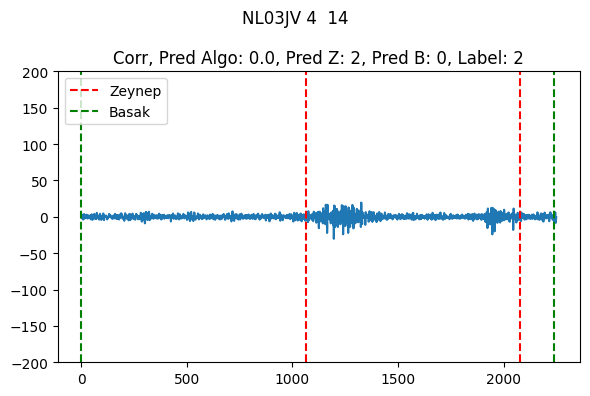

14


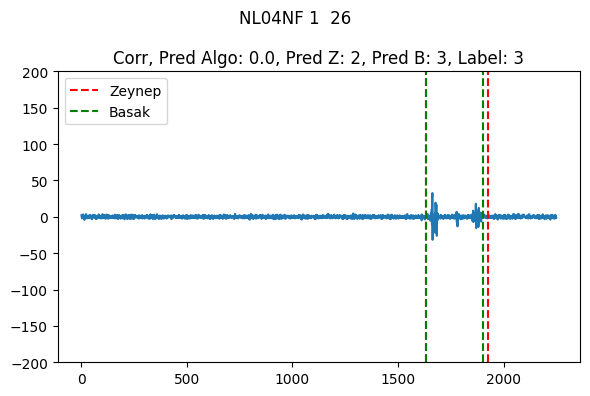

16


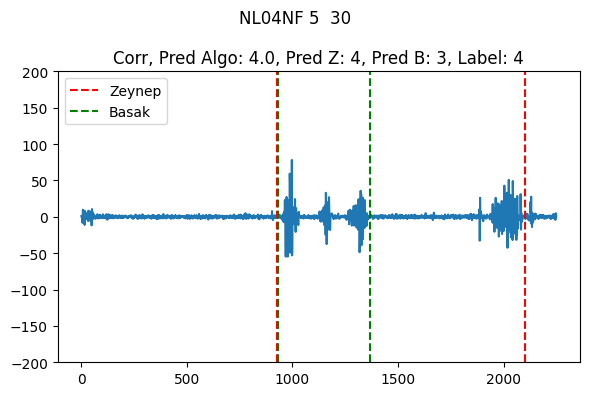

16


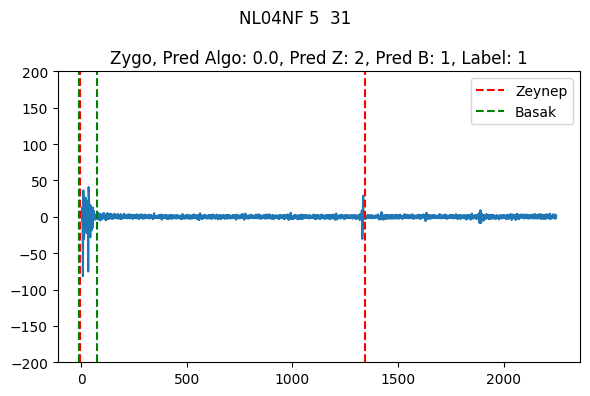

25


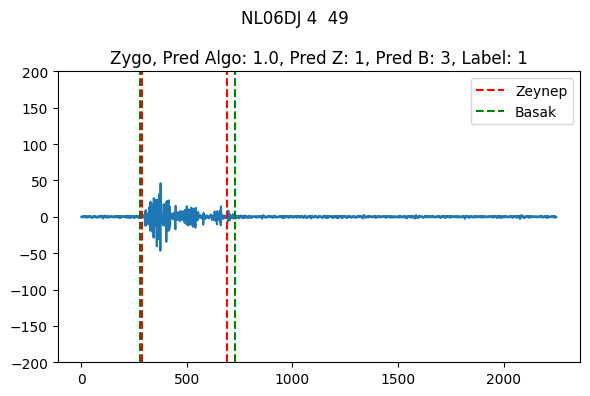

30


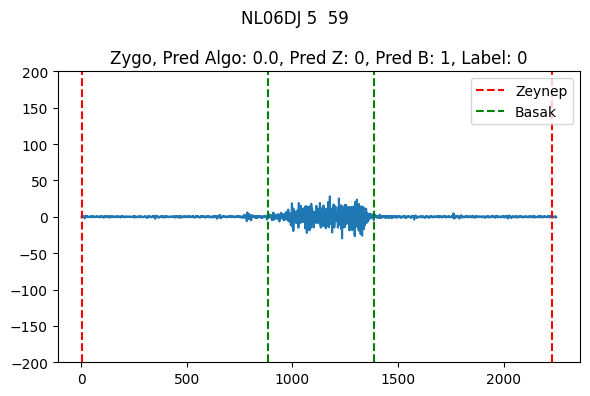

34


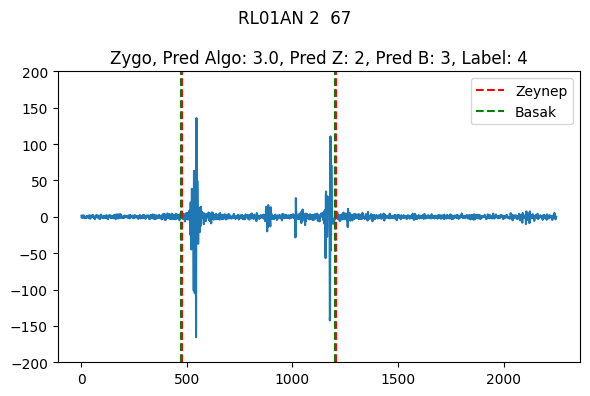

35


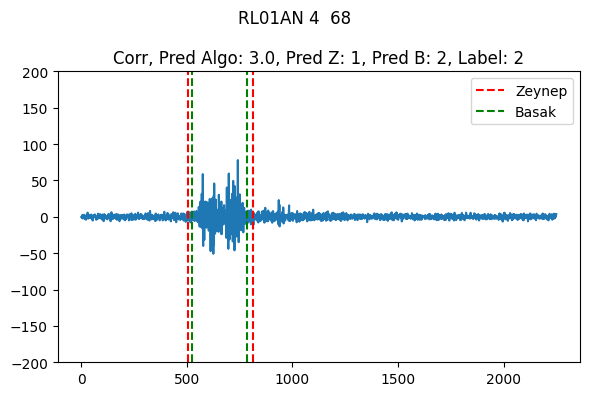

44


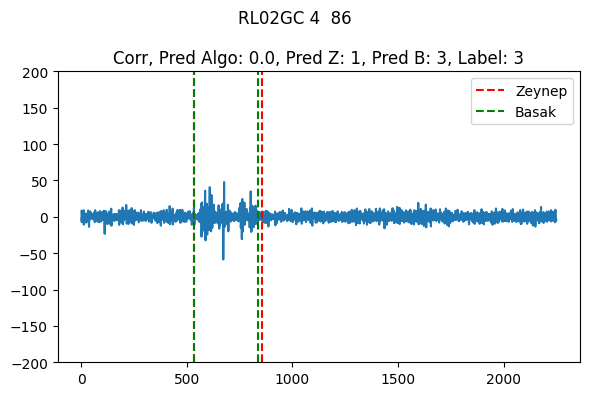

45


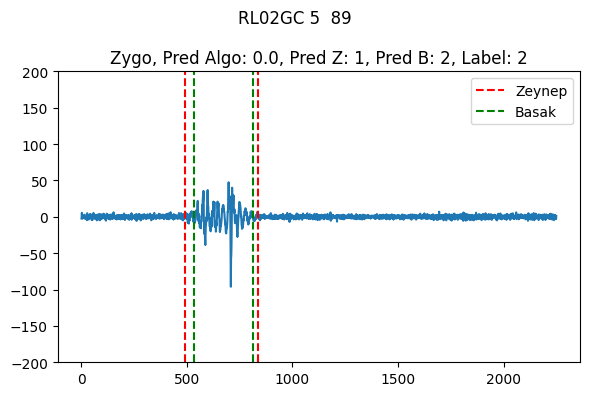

52


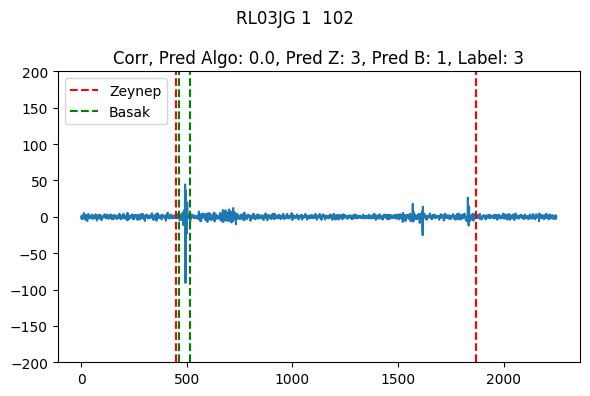

52


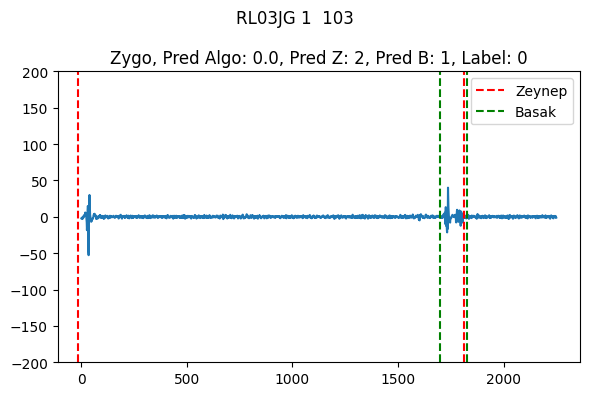

53


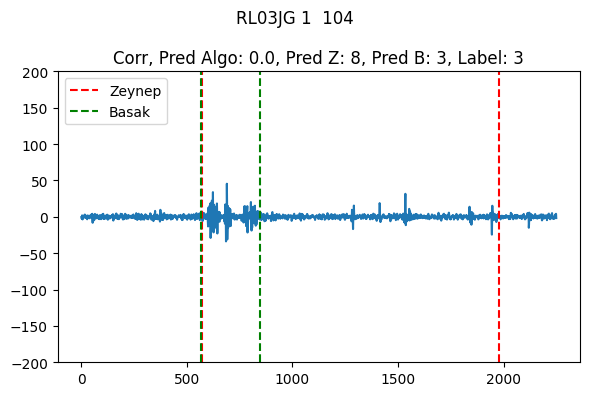

53


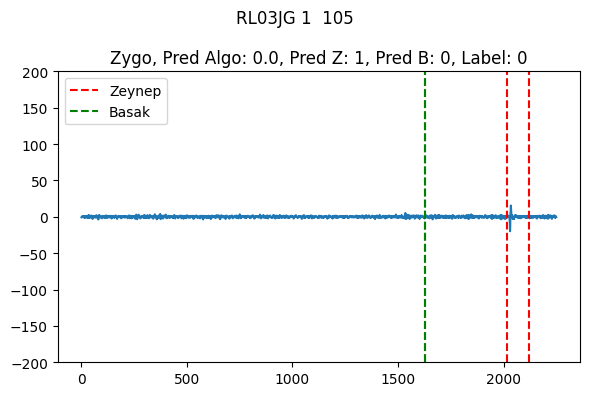

55


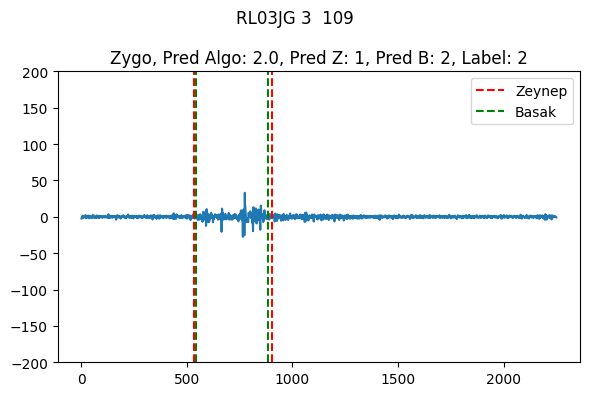

66


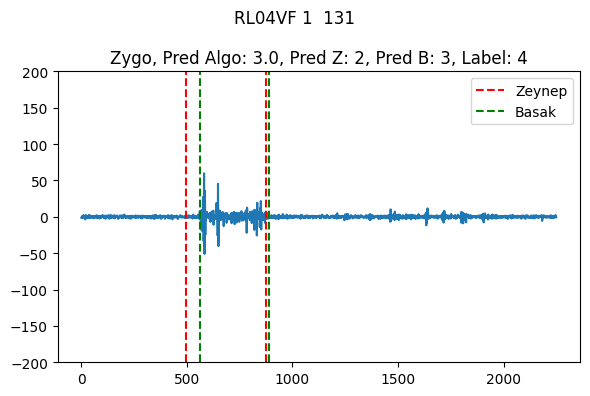

67


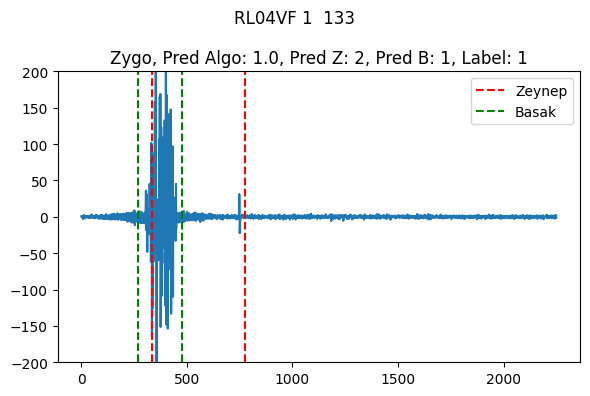

70


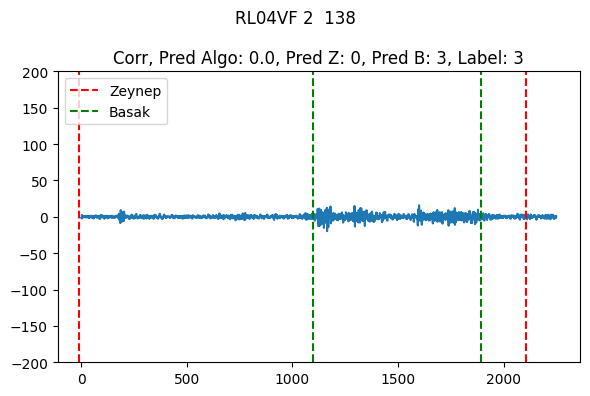

75


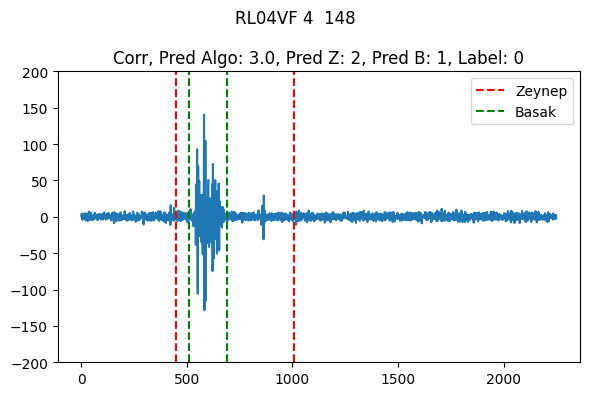

75


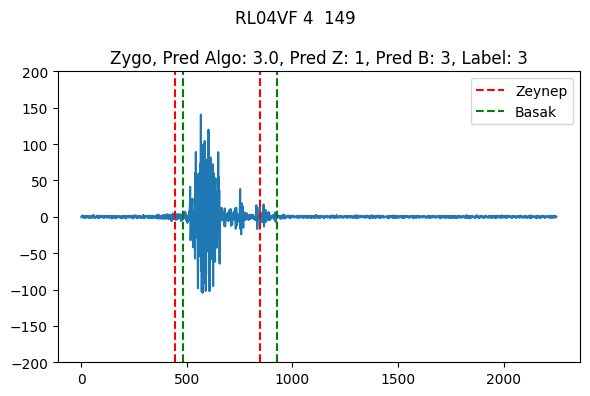

81


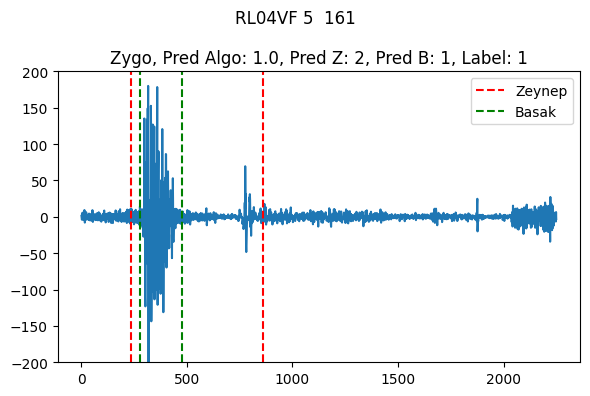

86


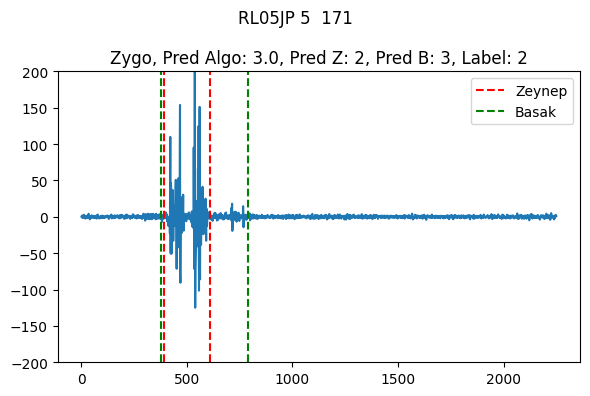

88


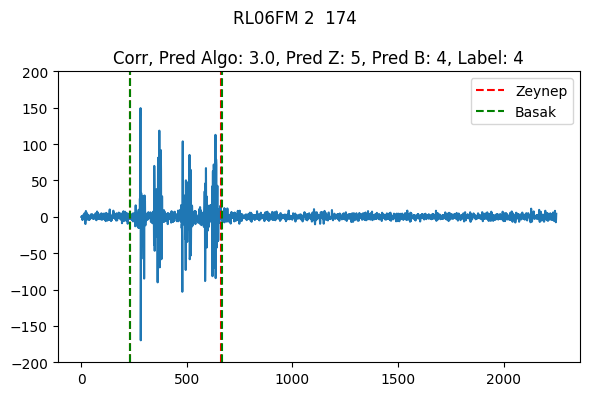

91


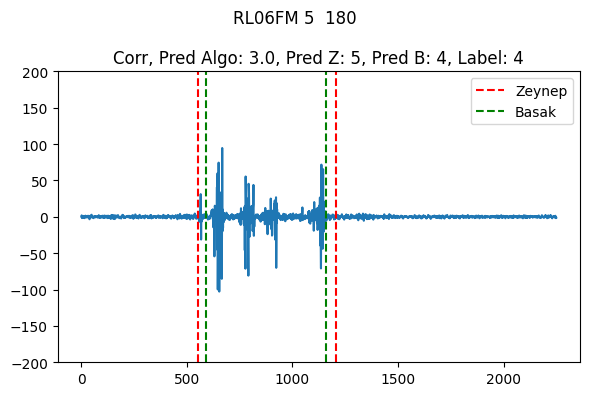

93


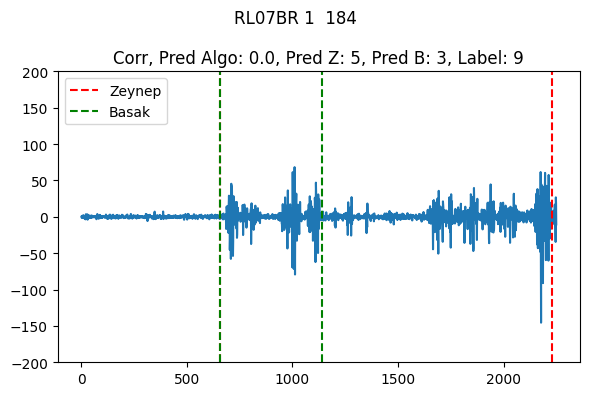

93


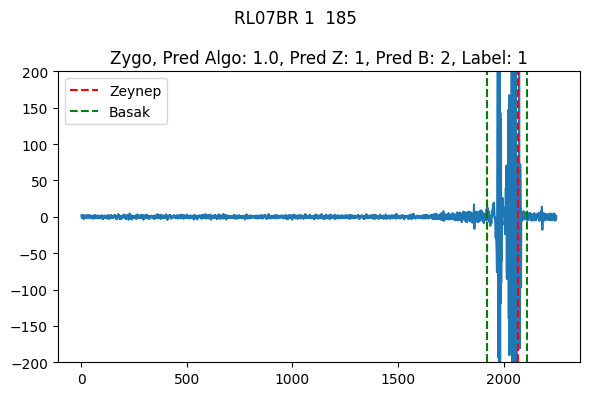

96


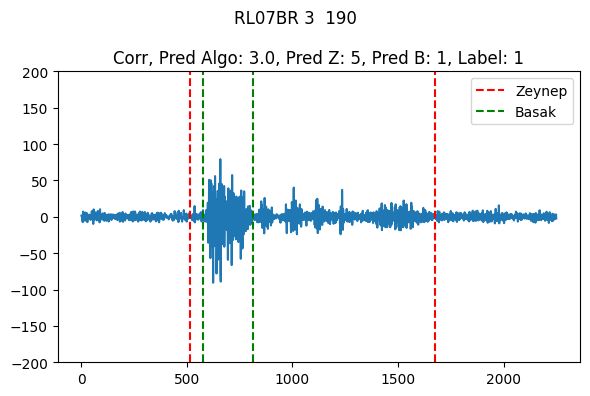

105


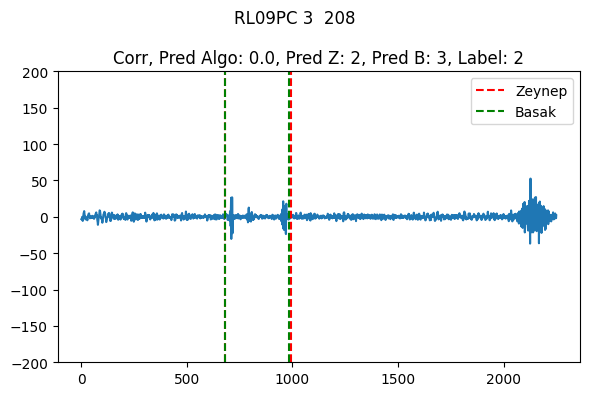

108


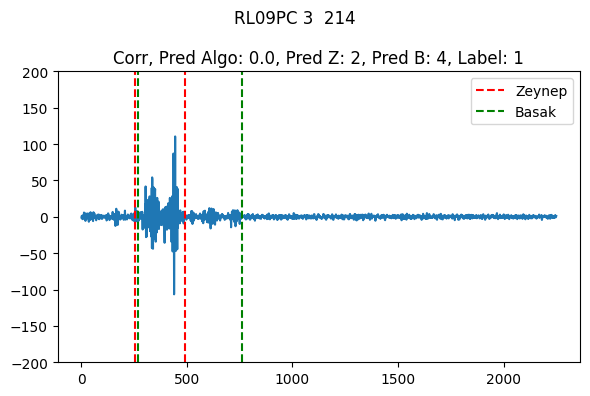

108


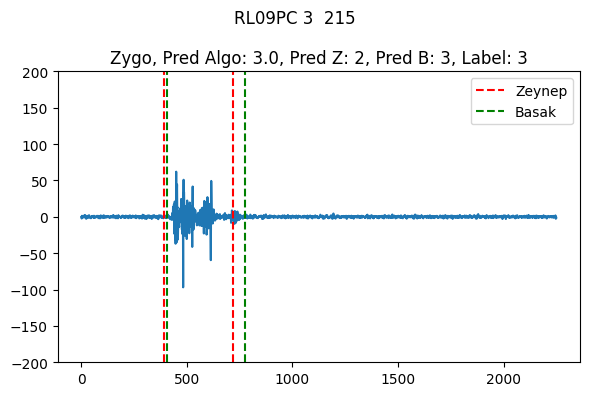

115


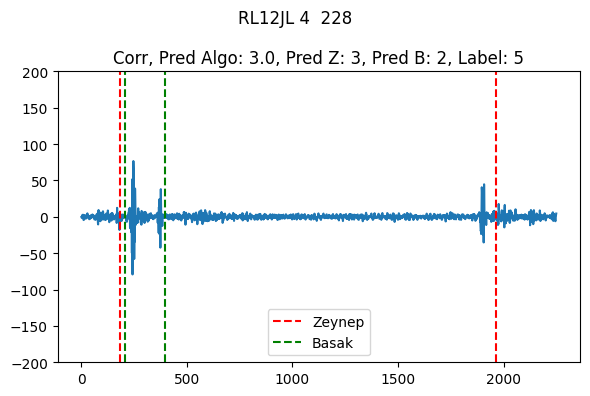

126


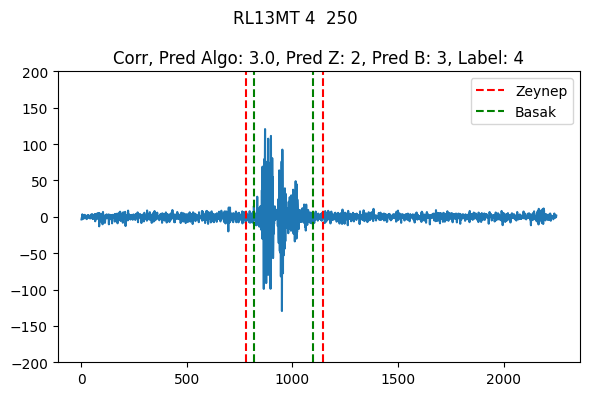

128


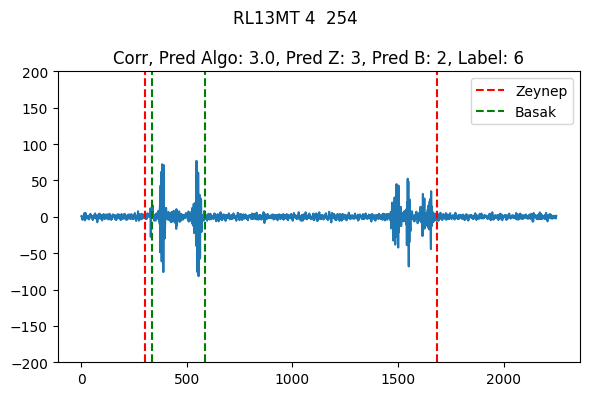

129


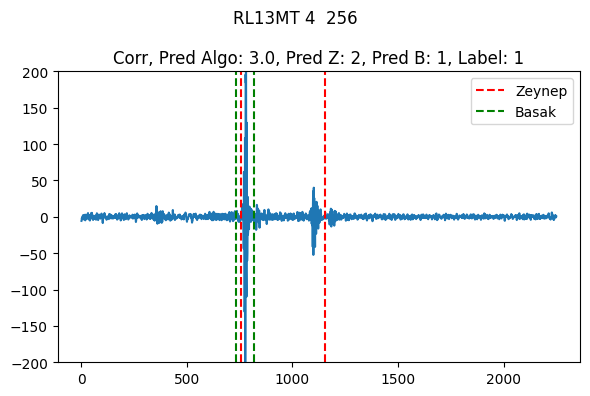

129


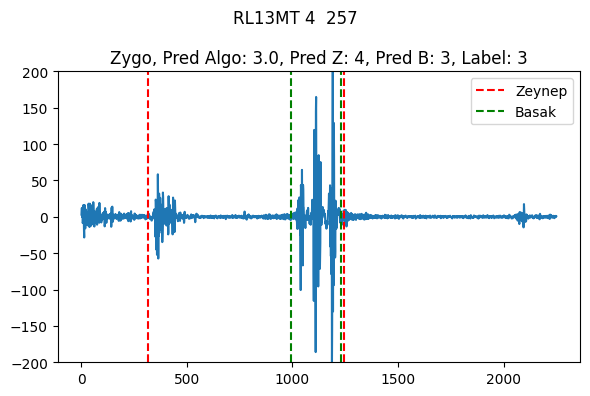

130


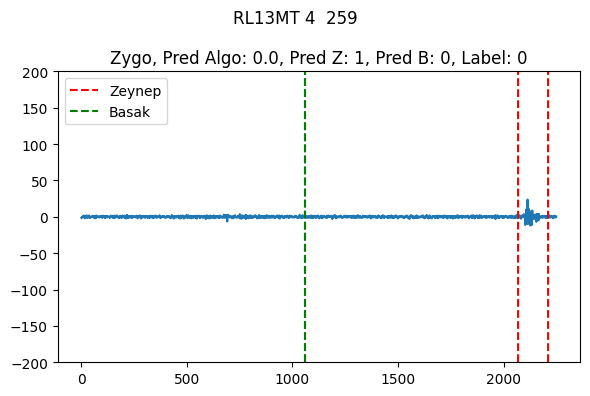

136


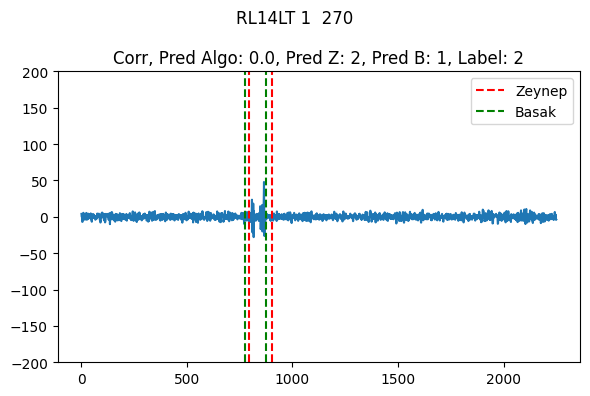

141


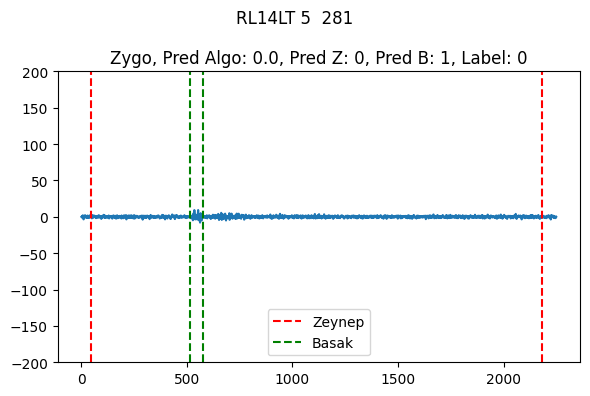

143


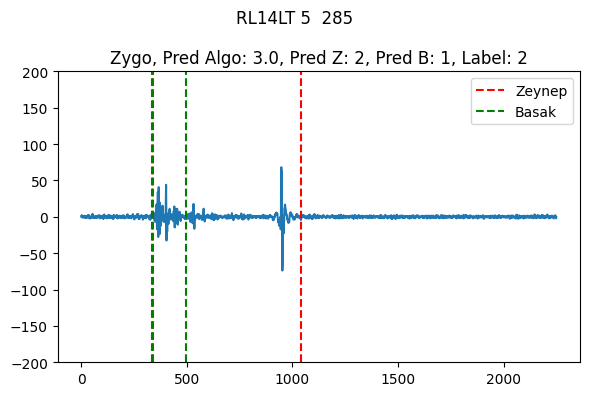

146


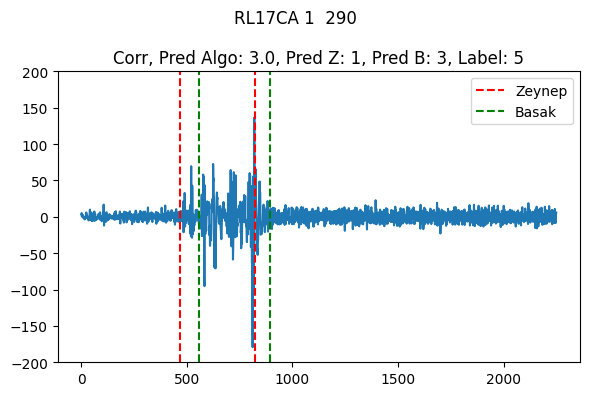

147


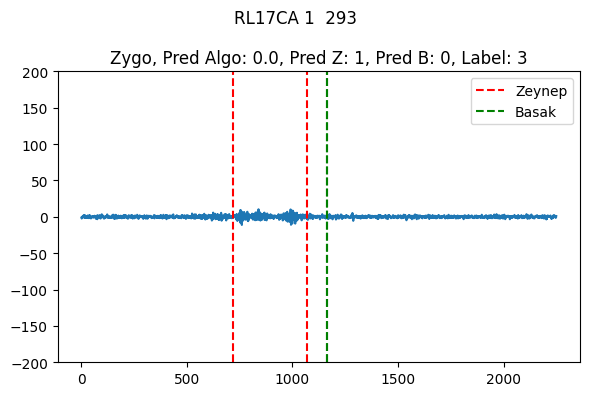

154


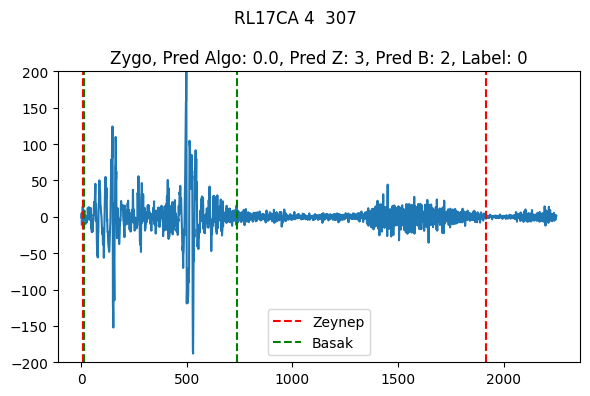

159


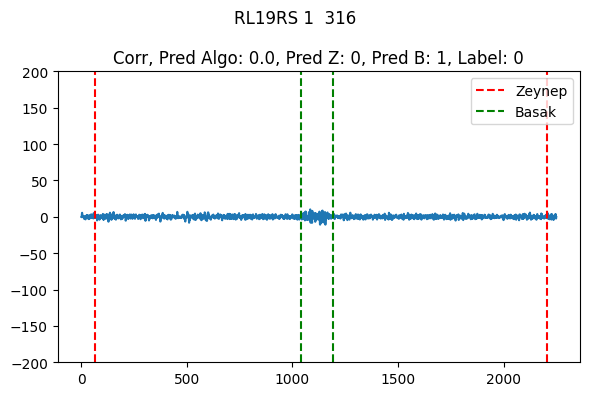

160


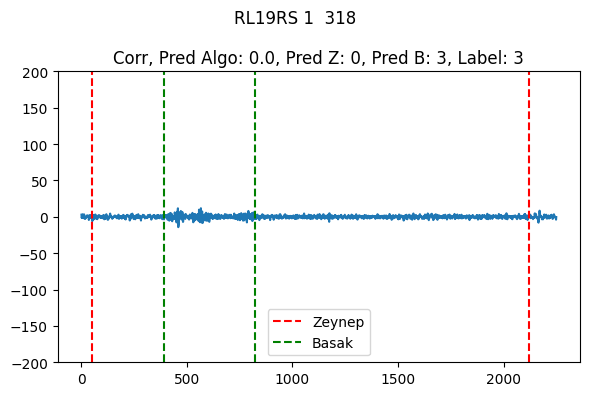

163


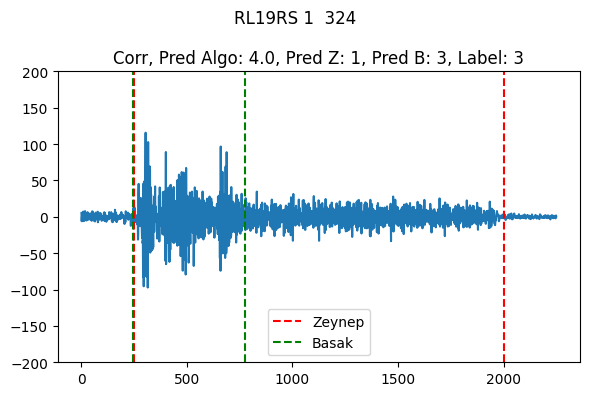

166


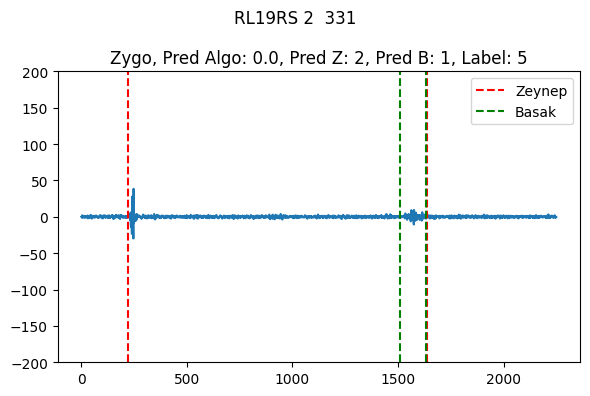

169


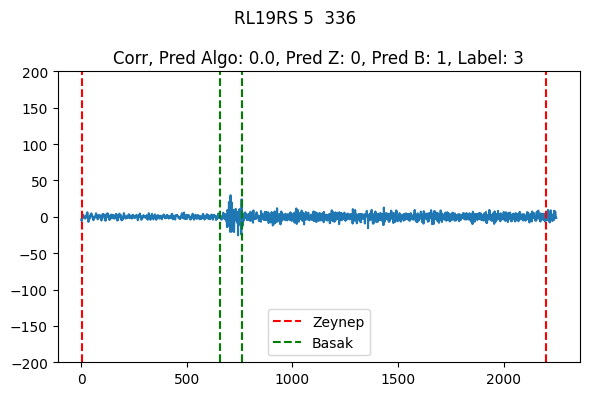

175


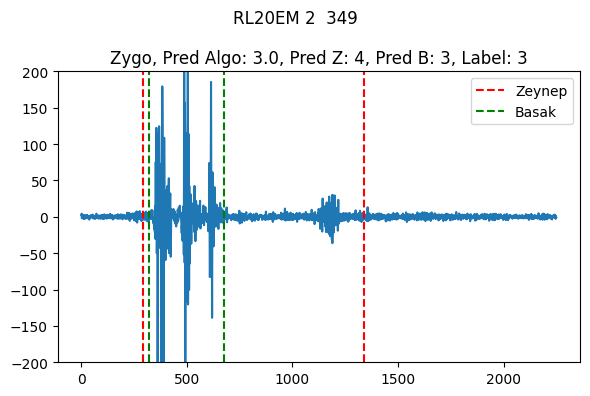

176


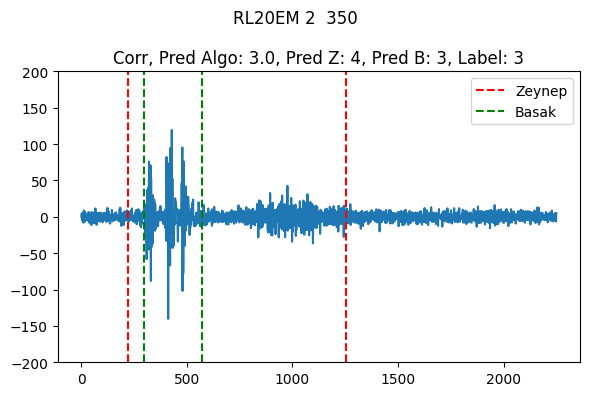

176


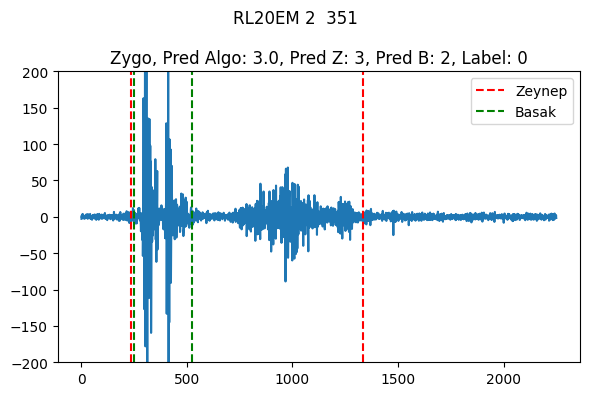

177


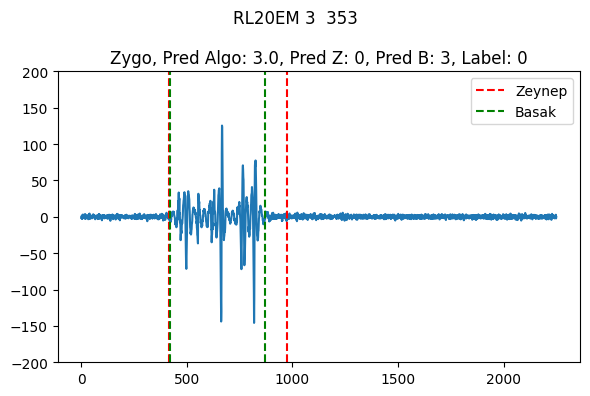

180


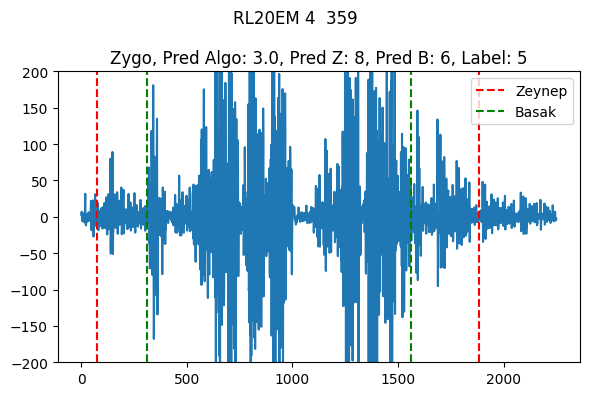

182


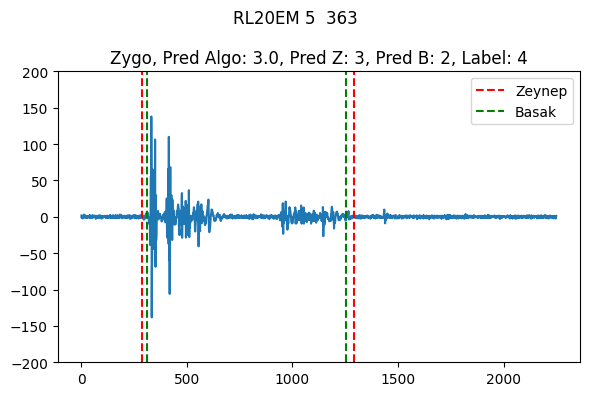

184


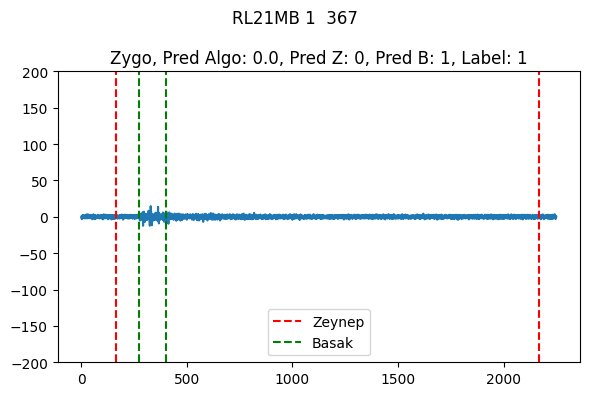

187


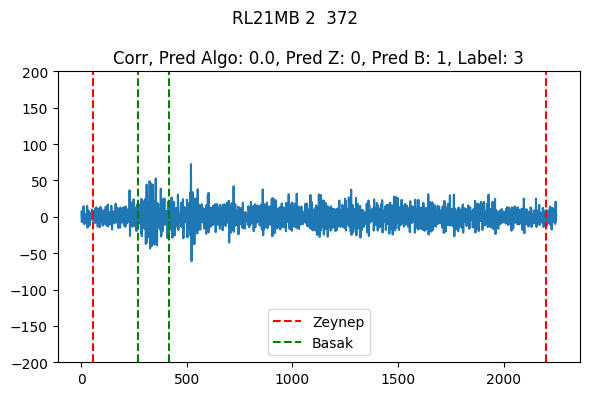

188


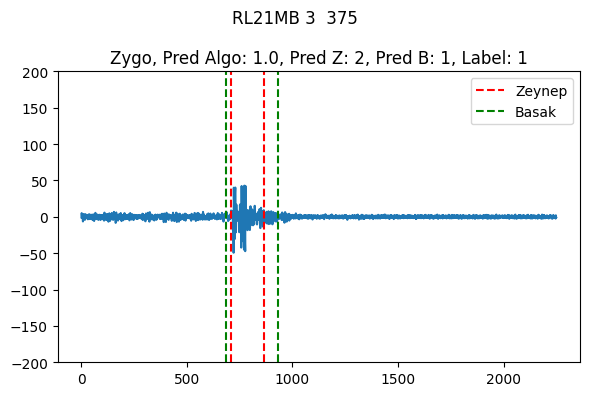

191


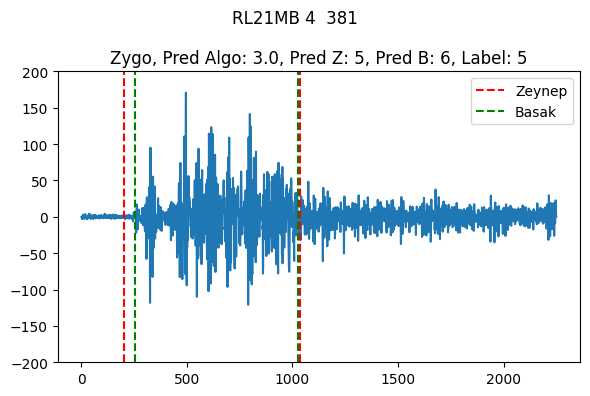

192


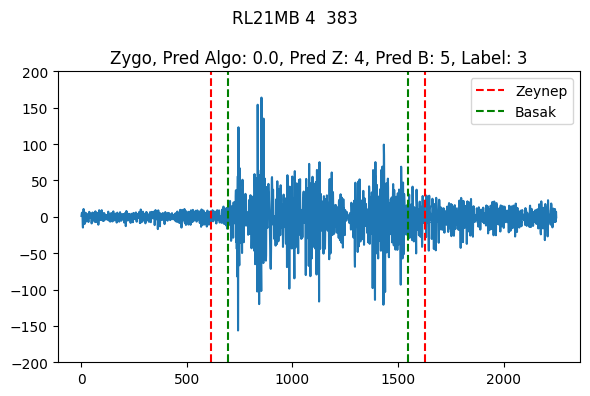

200


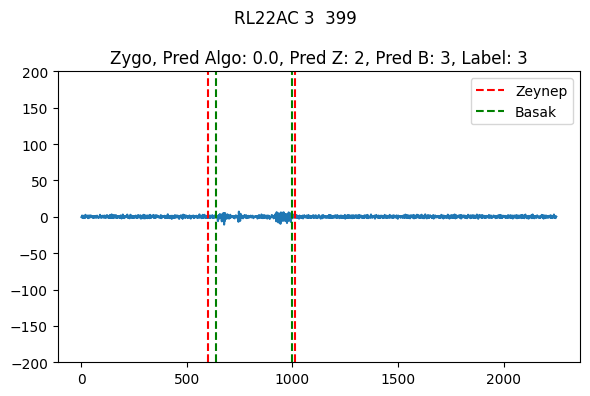

202


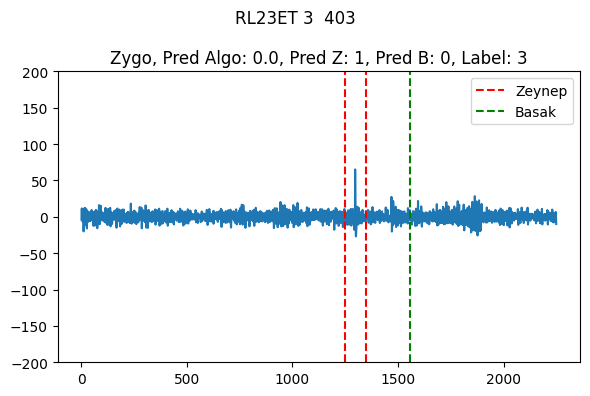

203


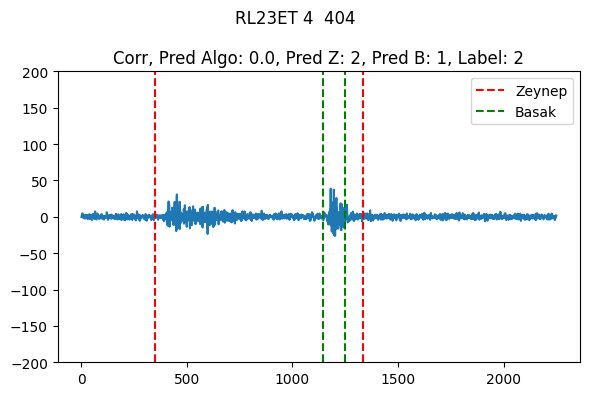

209


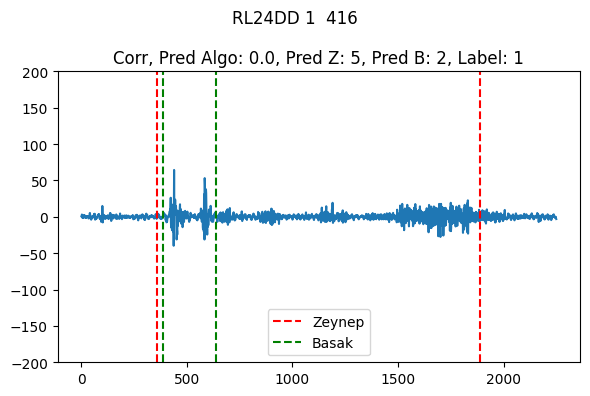

211


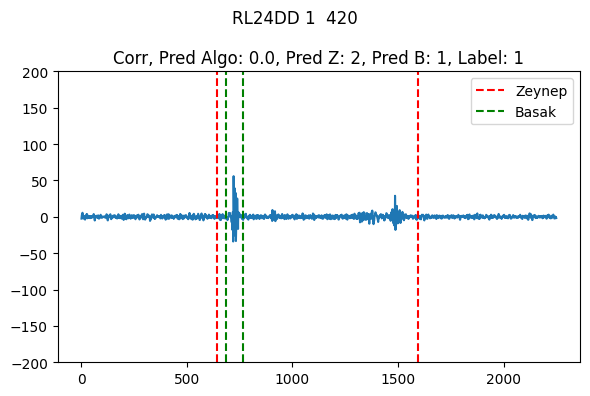

211


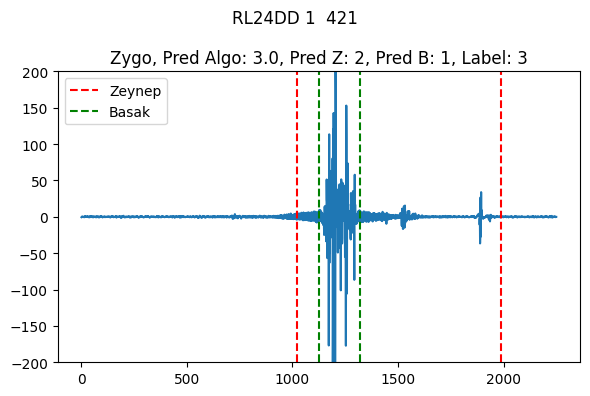

214


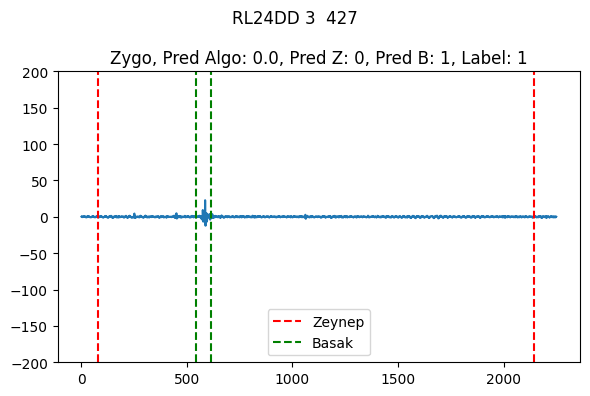

216


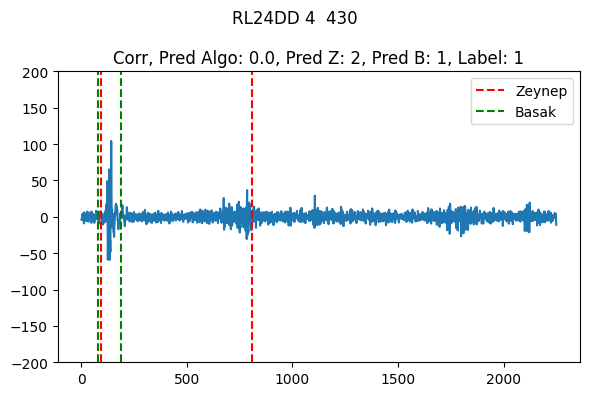

216


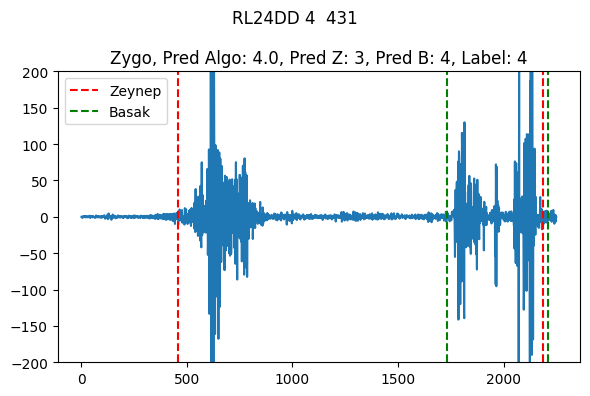

218


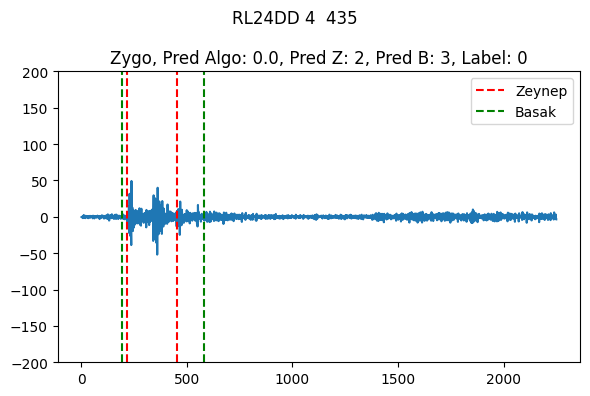

219


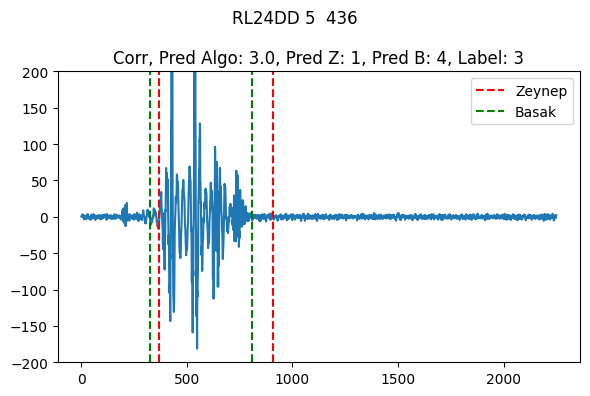

219


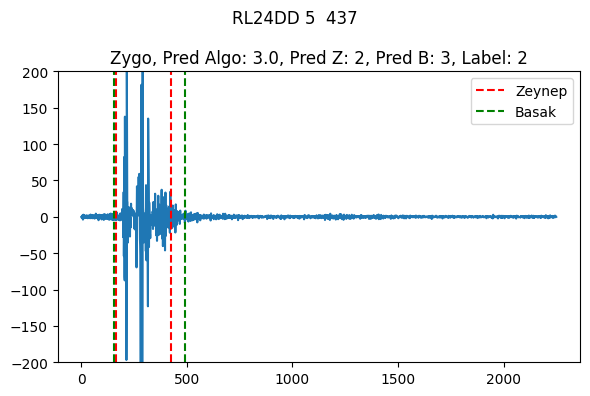

In [20]:
bl = np.where(((a==False) & (b==True))==True)[0]
tr = np.where(((a==True) & (b==False))==True)[0]
br = np.where(((a==False) & (b==False))==True)[0]
idx_all = [] 
mismatch = np.concatenate([tr, bl])

#print("Comparing instances where no matches between Zeynep, Başak, and Algorithm")
#print("Comparing instances where Başak matches Algorithm but Zeynep does not")
print("Comparing instances where no matches between Zeynep and Başak")


for idx in basak_zeynep_conflict_ind:
    plot_epoch(algo_scores_data, algo_scores, zeynep_scores,basak_scores,idx)

In [28]:
plt.close('all')